<a href="https://colab.research.google.com/github/lovenhatek/bigdata_assignment/blob/main/%ED%86%B5%EA%B3%84%EB%A1%9C_%EC%9A%94%EC%95%BD%ED%95%98%EA%B8%B0(4_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **통계로 요약하기**

통계를 사용하는 이유는 출력된 데이터를 읽는 것만으로는 무언가를 파악하기 어렵기 때문이다. 전체 에디어를 몇 개의 숫자로 요약할 수 있다면 현재 데이터의 특징을 이해하고 다른 데이터와 차이가 나는 점을 쉽게 설명할 수 있다.

## 기술통계 구하기

기술통계(descriptive statistics(=summary statistics))는 테크니컬한 어떤 것을 지칭하는 것이 아니라 자료의 내용을 압축하여 설명하는 방법을 말한다. 정량적인 수치로 전체 데이터의 특징을 요약하거나 이해하기 쉬운 간단한 그래프를 사용한다. 대표적인 통계량에는 평균, 표준편차가 있다.

데이터 시각화를 아우르는 이러한 데이터 분석 방법을 탐색적 데이터 분석(exploratory data analysis)이라고 한다.

이제부터는 남산도서관 대출 데이터에 들어있는 값의 특징을 하나씩 탐석하듯이 분석해 보도록 한다.

In [1]:
import gdown

gdown.download('https://bit.ly/3736JW1', 'ns_book6.csv', quiet=False)

Downloading...
From: https://bit.ly/3736JW1
To: /content/ns_book6.csv
100%|██████████| 55.0M/55.0M [00:00<00:00, 72.4MB/s]


'ns_book6.csv'

다운로드한 ns_book6.csv파일을 데이터프레임으로 불러온 후 처음 다섯 개 행을 출력하면 다음과 같다.

In [2]:
import pandas as pd
ns_book6 = pd.read_csv('ns_book6.csv', low_memory=False)
ns_book6.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021.0,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021.0,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021.0,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021.0,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021.0,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


판다스는 데이터프레임에서 기본적인 몇 가지 기술통계를 자동으로 추천해 주는 describe()메서드를 제공한다.

In [3]:
ns_book6.describe()

,번호,발행년도,도서권수,대출건수
count,379976.000000,379976.000000,379976.000000,379976.000000
mean,201726.332847,2008.516306,1.135874,11.504629
std,115836.454596,8.780529,0.483343,19.241926
min,1.000000,1947.000000,0.000000,0.000000
25%,102202.750000,2003.000000,1.000000,2.000000
50%,203179.500000,2009.000000,1.000000,6.000000
75%,301630.250000,2015.000000,1.000000,14.000000
max,401681.000000,2650.000000,40.000000,1765.000000


describe()메서드는 기본적으로 수치형 열에 대한 요약 통계를 보여준다.

이상한 점은 도서권수의 최솟값이 0이라는 점이다. 도서를 한 권도 가지고 있지 않은데 대출 데이터에 포함되어 있는 것이다.

이는 원래 소장한 도서이지만 분실된 도서인지, 혹은 더 이상 대출할 수 없는 도서인지 알 수 없으며, 이를 걸러내야 할지도 고려하여야 한다.

3장에서 했던 것처럼 불리언배열과 sum()함수를 활용하면 도서권수가 0인 도서의 행 개수를 쉽게 카운트할 수 있다.

In [4]:
sum(ns_book6['도서권수']==0)

3206

3,000개가 넘는 도서권수가 0이다.
전체 데이터에 비해서 1%가 채 되지 않는 수치이기 때문에 무시할 만하지만, 이러한 도서가 꽤 많다면 어떤 이유인지, 이를 제외할지 판단해야 한다.
처리 기준은 해결할 문제에 따라 다르며 이러한 결정이 분석 결과에 큰 영향을 미칠 수도 있다.

이 책에서는 실제로 없는 도서 대출 데이터는 의미가 없다고 생각하여 다음과 같이 제외한다.

In [5]:
ns_book7 = ns_book6[ns_book6['도서권수']>0]

다시 기술통계를 출력해보면,
describe()메서드는 기본적으로 25%, 50%, 75%에 위치한 값을 보여준다.

원하는 위치의 값을 보고 싶다면 percentiles매개변수에 위치를 지정하면 된다.

예를 들어 30%, 60%, 90%에 위치한 값을 보고 싶다면 소수점으로 0.3, 0.6, 0.9를 지정한다.

In [6]:
ns_book7.describe(percentiles=[0.3,0.6,0.9])

,번호,발행년도,도서권수,대출건수
count,376770.000000,376770.000000,376770.000000,376770.000000
mean,202977.476649,2008.460076,1.145540,11.593439
std,115298.245784,8.773148,0.473853,19.279409
min,1.000000,1947.000000,1.000000,0.000000
30%,124649.700000,2004.000000,1.000000,2.000000
50%,204550.500000,2009.000000,1.000000,6.000000
60%,243537.400000,2011.000000,1.000000,8.000000
90%,361341.100000,2018.000000,2.000000,28.000000
max,401681.000000,2650.000000,40.000000,1765.000000


열의 데이터 타입이 수치가 아닌 다른 데이터 타입의 열의 기술통계를 보고 싶다면 include매개변수의 데이터 타입을 지정할 수도 있다.

예를 들어 object타입의 열에 대한 통계를 보고 싶다면 다음과 같이 쓸 수 있다.

In [7]:
ns_book7.describe(include='object')

,도서명,저자,출판사,ISBN,세트 ISBN,부가기호,권,주제분류번호,등록일자
count,376770,376770,376770,376770,55866,308252,61793,359792,376770
unique,336408,248850,21875,350810,14875,17,834,12467,4562
top,승정원일기,세종대왕기념사업회 [편],문학동네,9788937430299,9788937460005,0,1,813.6,1970-01-01
freq,250,303,4410,206,702,158235,13282,14816,28185


count행은 누락된 값을 제외한 데이터 개수를 나타내고, unique행은 고유한 값의 개수를 나타낸다.

top행은 가장 많이 등장하는 값을 나타낸다.

freq행은 top행에 등장하는 항목의 빈도수이다.

실행 결과에 따르면 '도서명'열에서 가장 많이 등장하는 데이터는 '승정원일기'로 250회이다.

판다스의 describe()메서드는 이처럼 다양한 통계량을 간편하게 요약해서 확인할 수 있다.

이제 평균, 중앙값 등 개발 통계량에 대해 살펴본다.

In [45]:
x = [10, 20, 30]
sum = 0
for i in range(3):
  sum += x[i]
print("평균:", sum / len(x))

평균: 20.0


판다스 데이터프레임과 시리즈 객체는 평균을 계산하는 mean메서드를 제공한다.
평균 대출건수는 약 11.6으로 describe()메서드를 출력해서 본 것과 같다.

In [9]:
ns_book7['대출건수'].mean()

np.float64(11.593438968070707)

중앙값은 말 그대로 전체 데이터를 순서대로 늘어놓았을 때 중앙에 위치한 값이다.

앞서 describe()메서드의 기본 출력에서 25%, 50%, 75% 위치의 값이 출력되었는데, 이 중에서 50% 위치의 값이 중앙값에 해당한다.

판다스는 중앙값을 구하기 위한 메서드를 따로 제공한다.

In [10]:
ns_book7['대출건수'].median()

6.0

데이터 개수가 홀수일 때는 중앙값을 결정하기 쉽다.

정확히 가운데 놓인 값을 찾으면 된다. 하지만 짝수일 때 중앙값을 결정하는 방법은?

In [11]:
temp_df = pd.DataFrame([1,2,3,4])
temp_df.median()

,0
0,2.5


데이터 개수가 짝수이면 가운데 두 개의 값을 평균하여 중앙값을 결정한다.

예를 들어, 위처럼 1~4 네 개의 값으로 이루어진 데이터프레임에서 중앙값을 구하면 2와 3을 평균한 2.5가 중앙값이 된다.

같은 값의 대출건수를 모두 제외하고 중앙값을 계산할 수도 있다.
drop_duplicate()메서드를 사용해 '대출건수' 열에서 중복된 값을 가진 행을 제거한 후 중앙값을 구하면 다음과 같다.

In [12]:
ns_book7['대출건수'].drop_duplicates().median()

183.0

중복된 값을 제거하니 중앙값이 굉장히 높아진다.

이 결과로 미루어 보면 작은 대출건수에 중복된 행이 많을 것이라고 생각할 수 있다.

얼마나 많은 값이 중복되어 있을지는 추후 그래프를 그려보며 알아보자.

## 최솟값, 최댓값

중앙값과 함께 자주 사용되는 통계량을 최솟값과 최댓값이다.
판다스에서는 각각 min()메서드와 max()메서드를 제공한다.

In [13]:
ns_book7['대출건수'].min()

0

In [14]:
ns_book7['대출건수'].max()

1765

## 분위수(quartile)

분위수는 데이터를 순서대로 늘어놓았을 때 이를 균등한 간격으로 나누는 기준점이다.
예를 들어, 이분위수는 전체 데이터를 두 구간으로 나누기 때문에 중앙값에 해당한다.
많이 사용하는 사분위수는 순서대로 정렬된 데이터를 네 구간으로 나눈다.
따라서 사분위수는 3개가 나오고 각각 25%, 50%, 75%에 해당한다.

25%에 해당하는 값 - 제1사분위수

50%에 해당하는 값 - 제2사분위수

75%에 해당하는 값 - 제3사분위수

##quantile()메서드

판다스에서 분위수 값을 계산할 때는 quantile()메서드를 사용한다.

하위 25%에 위치한 값을 출력하려면 0.25를 입력한다.

In [15]:
ns_book7['대출건수'].quantile(0.25)

np.float64(2.0)

quantile()메서드에 여러 개의 분위수를 지정할 수도 있다.

다음처럼 25%, 50%, 75%에 위치한 값을 추출해 보겠다.

In [16]:
ns_book7['대출건수'].quantile([0.25,0.5,0.75])

,대출건수
0.25,2.0
0.50,6.0
0.75,14.0


이처럼 quantile()메서드에 여러 개의 분위수를 지정하면 각 분위수에 해당하는 값을 담은 시리즈 객체를 반환한다.

그렇다면 다음과 같이 1,2,3,4,5 다섯 개의 숫자가 있을 때 90% 위치에 있는 값은 얼마일까?

시리즈 객체를 정의한 후 분위수를 구해보면 다음과 같다.

In [17]:
pd.Series([1,2,3,4,5]).quantile(0.9)

np.float64(4.6)

이 시리즈 객체에 4.6이라는 값이 없는데 출력되었다. 이 값은 어떻게 계산되었을까?

quantile()메서드는 interpolation매개변수에서 중간값을 계산하는 방법을 결정한다.

위 코드는 interpolation매개변수를 따로 지정하지 않아서 기본값으로 계산된 것이다.

예를 들어 4와 5 사이에서 90%에 해당하는 분위수를 찾을 때, 4의 분위수 0.75와 5의 분위수 1.0을 사용해 간단한 비례식을 세울 수 있다.
여기서 궁금한 값 b에 대해 정리하면 아래와 같은 식을 얻게 된다.

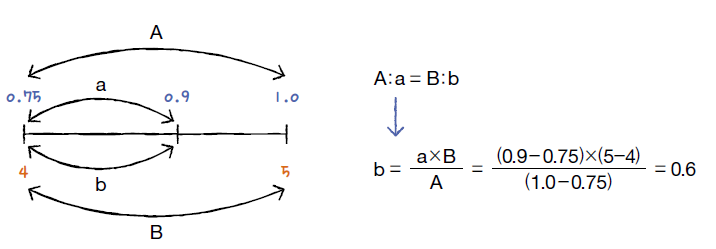

이렇게 두 지점 사이에 놓인 특정 위치의 값을 구하는 방법을 보간(interpolation)이라고 부른다.

In [18]:
4 + (0.9-0.75)*(5-4)/(1.0-0.75)

4.6

In [19]:
pd.Series([1,2,3,4,5]).quantile(0.9, interpolation='midpoint')

np.float64(4.5)

interpolation매개변수는 'linear' 외에도 여러가지 다른 보간 방식을 제공한다.

'midpoint'는 분위수에 상관없이 무조건 두 수 사이의 중앙값을 사용한다.

In [20]:
pd.Series([1,2,3,4,5]).quantile(0.9, interpolation='nearest')

np.int64(5)

'nearest'는 두 수 중에서 가까운 값을 선택한다. 이 경우는 0.9가 1.0에 더 가깝기 때문에 5가 된다.

##백분위 구하기

판다스에서 대출건수 n이 위치한 백분위를 찾는 메서드를 제공하지는 않지만, 간단한 트릭으로 유사한 결과를 얻을 수 있다.

먼저 '대출건수'열의 값이 10보다 작은지 비교하여 불리언배열을 만든다.

In [21]:
borrow_10_flag = ns_book7['대출건수'] < 10

이렇게 변환한 borrow_10_flag배열(실제로는 시리즈 객체임)에서 True인 개수를 모두 헤아린 후 전체 데이터 개수로 나누면 10보다 작은 대출건수의 비율을 얻을 수 있다.

데이터 양이 많다면 전체 데이터를 순서대로 놓았을 때 10이 위치한 백분위와 거의 비슷하게 된다.

판다스에서 불리언 자료를 산술 연산하면 True는 1, False는 0으로 취급한다.

따라서, 다음처럼 borrow_10_flag배열에서 mean()메서드를 호출하여 평균을 구하면 10보다 작은 값이 차지하는 비율을 간단히 얻을 수 있다.

In [22]:
borrow_10_flag.mean()

np.float64(0.6402712530190833)

그럼 10에 대한 백분위는 0.65정도가 된다.

quantile()메서드에 백분위를 넣어 직접 확인해 보면 10이 출력된다.

In [23]:
ns_book7['대출건수'].quantile(0.65)

np.float64(10.0)

##분산(Variance)

분산은 평균으로부터 데이터가 얼마나 퍼져 있는지를 나타내는 통계량이다.

데이터가 가운데 모여 있다면 분산이 작고 넓게 퍼져 있다면 분산이 크다.

분산은 데이터의 각 값에서 평균을 뺀 다음 제곱한 후 평균처럼 샘플 개수로 나누어 구할 수 있다.

In [24]:
ns_book7['대출건수'].var()

371.6956304306922

분산은 제곱을 했기 때문에 데이터가 평균에서 멀어질수록 값이 급격하게 커진다.

또 단위가 대출건수의 제곱이 되어 해석하기 조금 어렵다.

이를 보완하기 위해 표준편차를 사용한다.

##표준편차(Standard Variation)

표준편차는 분산에 제곱근을 한 것으로 수식 기호는 s를 사용한다.

반대로 말하면 분산은 표준편차를 제곱한 것이므로, 분산은 s제곱으로 표시했던 것이다.

In [25]:
ns_book7['대출건수'].std()

19.27940949382766

앞서 도서대출 건수는 평균 11회가 조금 넘는 것을 알 수 있었는데, 어떤 도서의 대출 건수를 확인했을 때 평균보다 19만큼 더 많거나 적을 수 있다는 의미이다.

그런데, 평균이 11 언저리인데 표준편차가 19이면 너무 크고, 대출건수는 음수가 될 수 없기 때문에 이상한 것이 아닌가 생각할 수 있다.

평균보다 훨씬 큰 대출건수가 있기 때문에 표준편차가 큰 것이라고 예상하면 된다.

판다스의 넘파이를 사용해 표준편차를 수식대로 직접 계산해서 판다스의 std()메서드를 사용한 결과와 동일한지 확인해보자.

In [26]:
import numpy as np
diff = ns_book7['대출건수'] - ns_book7['대출건수'].mean()
np.sqrt(np.sum(diff**2) / (len(ns_book7)-1))

np.float64(19.279409493785508)

## 최빈값 구하기

기술통계의 마지막으로 최빈값이다.

최빈값(mode)은 데이터에서 가장 많이 등장하는 값을 의미한다.

앞서 출력한 describe(include='object')의 출력 중에 top행에 나온 값이 바로 최빈값이다.

판다스에서 mode()메서드는 최빈값을 계산한다.

도서명에서 가장 많이 등장하는 값을 찾아보면 describe()메서드와 출력이 동일한 것을 볼 수 있다.

In [27]:
ns_book7['도서명'].mode()

,도서명
0,승정원일기


mode()메서드는 텍스트뿐만 아니라 수치형에도 똑같이 적용할 수 있다.

남산도서관 대출 데이터에서 가장 많이 등장하는 연도는 무엇인지 알아보자.

In [28]:
ns_book7['발행년도'].mode()

,발행년도
0,2012.0


남산도서관은 2012년도 도서를 가장 많이 소장하고 있다.

지금까지 주로 판다스 시리즈 객체에서 메서드를 호출해 기술통계를 구하는 방법을 알아보았다.

이런 메서드들은 대부분 판다스 데이터프레임에서도 직접 호출할 수 있다.

## 데이터프레임에서 기술통계 구하기

지금까지 평균, 중앙값, 최솟값, 최댓값, 분위수, 분산, 표준편차를 구할 수 있는 다양한 판다스 메서드를 알아보았다.

이런 메서드들은 데이터프레임에서도 사용할 수 있다.

수치형 열만 있으면 연산할 수 있기 때문에, 해당 열에만 적용되도록 numeric_only매개변수를 True로 지정하여야 한다.

예를 들어 ns_book7 데이터프레임에서 mean()메서드를 호출하면 수치형인 네 개의 열에 대한 평균값이 계산된다.

만약 numeric_only매개변수를 지정하지 않을 경우, 모든 데이터 타입의 열에 대해 수행하기 때문에 시간이 매우 오래 걸리며 경고가 발생한다.

In [29]:
ns_book7.mean(numeric_only=True)

,0
번호,202977.476649
발행년도,2008.460076
도서권수,1.145540
대출건수,11.593439


mode()메서드도 데이터프레임에서 호출할 수 있다.

ns_book7의 '번호'열은 모두 고유한 값으로서, 최빈값을 찾는 것이 의미가 없다.

따라서, loc메서드로 '도서명' 열부터 마지막 열까지에 대해 최빈값을 찾으면 다음과 같다.

In [30]:
ns_book7.loc[:, '도서명':].mode()

,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,승정원일기,세종대왕기념사업회 [편],문학동네,2012.0,9788937430299,9788937460005,0,1,813.6,1,0,1970-01-01


'도서명' 열에서 가장 많이 등장하는 값은 '승정원일기'이고 '출판사' 열에서 가장 많이 등장하는 것은 '문학동네'이다.

이때, 결과값만 보고 '승정원일기'가 '문학동네' 출판사의 도서라고 오해하면 안 된다.

mode()메서드 출력 결과물간의 사이는 아무런 연관이 없다는 것을 주의해야 한다.

In [31]:
ns_book7.to_csv('ns_book7.csv', index=False)

마지막으로, ns_book7데이터프레임을 csv파일로 저장한다.

## 넘파이의 기술통계 함수

### 평균 구하기

In [32]:
import numpy as np

np.mean(ns_book7['대출건수'])

np.float64(11.593438968070707)

In [33]:
np.average(ns_book7['대출건수'], weights = 1/ns_book7['도서권수'])

np.float64(10.543612175385386)

In [34]:
np.mean(ns_book7['대출건수']/ns_book7['도서권수'])

np.float64(9.873029861445774)

In [35]:
ns_book7['대출건수'].sum()/ns_book7['도서권수'].sum()

np.float64(10.120503701300958)

### 중앙값 구하기

In [36]:
np.median(ns_book7['대출건수'])

np.float64(6.0)

### 최솟값, 최댓값 구하기

In [37]:
np.min(ns_book7['대출건수'])

0

In [38]:
np.max(ns_book7['대출건수'])

1765

### 분위수 구하기

In [39]:
np.quantile(ns_book7['대출건수'], [0.25,0.5,0.75])

array([ 2.,  6., 14.])

###분산 구하기

In [40]:
np.var(ns_book7['대출건수'])

371.694643898775

In [41]:
ns_book7['대출건수'].var(ddof=0)

371.694643898775

In [42]:
np.var(ns_book7['대출건수'], ddof=1)

371.6956304306922

###표준편차 구하기

In [43]:
np.std(ns_book7['대출건수'])

19.279383908693113

### 최빈값 구하기

In [44]:
values, counts = np.unique(ns_book7['도서명'], return_counts=True)
max_idx = np.argmax(counts)
values[max_idx]

'승정원일기'



---